# NYC Airbnb — Data Cleaning, EDA & Price Prediction

This notebook complements the [Tableau dashboard](https://public.tableau.com/views/NewYorkCityAirbnb_17768523314010/Dashboard1) with a reproducible Python analysis of the same dataset (`AB_NYC_2019.csv`, 48,895 listings):

1. **Cleaning** — handle missing values, invalid prices, and extreme minimum-stay values
2. **Exploratory analysis** — what actually drives listing price
3. **Price prediction** — can listing attributes predict nightly price, and how much better than a simple baseline?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", "{:,.2f}".format)
plt.rcParams.update({"figure.dpi": 90, "axes.spines.top": False, "axes.spines.right": False})
RANDOM_STATE = 42

df = pd.read_csv("AB_NYC_2019.csv", parse_dates=["last_review"])
print(df.shape)
df.head()

(48895, 16)


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaT,NaN,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


## 1. Data quality

In [2]:
missing = df.isna().sum()
missing[missing > 0]

name                    16
host_name               21
last_review          10052
reviews_per_month    10052
dtype: int64

- `reviews_per_month` and `last_review` are missing for the **same** rows — listings that have **never been reviewed**, not corrupted data. So `reviews_per_month` is filled with 0, and "has never been reviewed" is kept as its own feature.
- `name` / `host_name` gaps are tiny and not used for modelling.

In [3]:
print("Listings with price = $0:        ", (df.price == 0).sum())
print("Listings with price > $1,000:    ", (df.price > 1000).sum())
print("Listings with min. nights > 365: ", (df.minimum_nights > 365).sum())
df.price.describe(percentiles=[.5, .9, .99, .999])

Listings with price = $0:         11
Listings with price > $1,000:     239
Listings with min. nights > 365:  14


count   48,895.00
mean       152.72
std        240.15
min          0.00
50%        106.00
90%        269.00
99%        799.00
99.9%    3,000.00
max     10,000.00
Name: price, dtype: float64

**Cleaning decisions**

- **$0 prices** are invalid (a listing can't be free) → dropped.
- **Prices above $1,000/night** are 0.5% of listings but the mean price is pulled far above the median by them. They're a mix of genuine luxury listings and placeholder prices (e.g. $10,000), which can't be told apart from this data → excluded from modelling, and the model's scope is stated as *listings up to $1,000/night*.
- **Minimum nights** are capped at 365 — values like 1,250 nights are not realistic short-term rentals.

In [4]:
clean = df[(df.price > 0) & (df.price <= 1000)].copy()
clean["minimum_nights"] = clean.minimum_nights.clip(upper=365)
clean["reviews_per_month"] = clean.reviews_per_month.fillna(0)
clean["never_reviewed"] = clean.last_review.isna().astype(int)
ref_date = clean.last_review.max()
clean["days_since_review"] = (ref_date - clean.last_review).dt.days
print(f"Kept {len(clean):,} of {len(df):,} listings ({len(clean)/len(df):.1%})")

Kept 48,645 of 48,895 listings (99.5%)


## 2. Exploratory analysis

### Price is heavily right-skewed

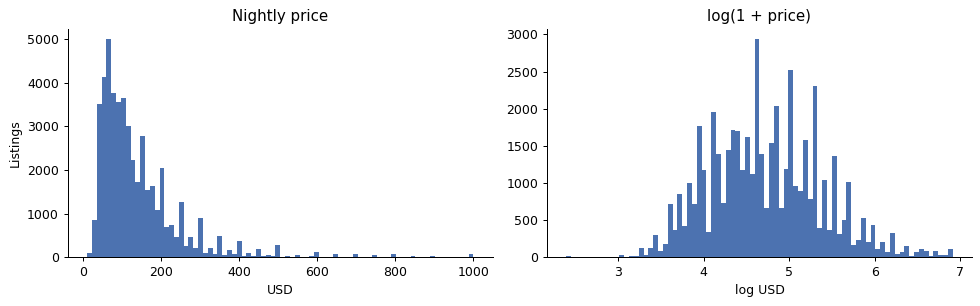

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
axes[0].hist(clean.price, bins=80, color="#4C72B0")
axes[0].set(title="Nightly price", xlabel="USD", ylabel="Listings")
axes[1].hist(np.log1p(clean.price), bins=80, color="#4C72B0")
axes[1].set(title="log(1 + price)", xlabel="log USD")
plt.tight_layout(); plt.show()

The log of price is close to symmetric, so the model predicts **log-price** and converts back to dollars for evaluation.

### Room type and borough

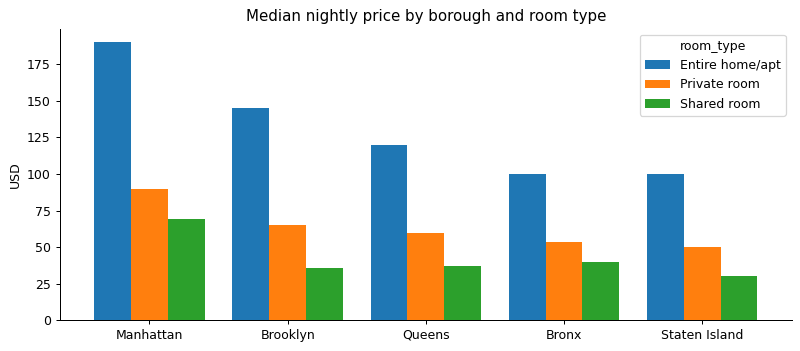

room_type,Entire home/apt,Private room,Shared room
neighbourhood_group,,,
Manhattan,190.00,90.00,69.00
Brooklyn,145.00,65.00,36.00
Queens,120.00,60.00,37.00
Bronx,100.00,53.50,40.00
Staten Island,100.00,50.00,30.00


In [6]:
pivot = clean.pivot_table(index="neighbourhood_group", columns="room_type",
                          values="price", aggfunc="median")
pivot = pivot.loc[pivot["Entire home/apt"].sort_values(ascending=False).index]
ax = pivot.plot.bar(figsize=(9, 4), rot=0, width=0.8)
ax.set(title="Median nightly price by borough and room type", ylabel="USD", xlabel="")
plt.tight_layout(); plt.show()
pivot

### Location matters inside boroughs too

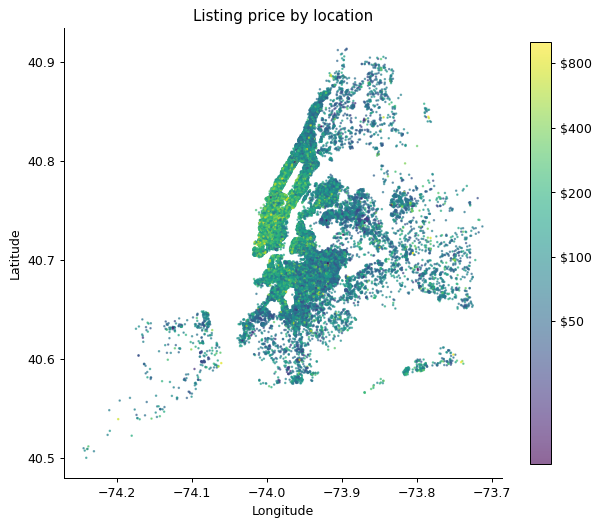

In [7]:
fig, ax = plt.subplots(figsize=(7, 7))
sc = ax.scatter(clean.longitude, clean.latitude, c=np.log1p(clean.price),
                s=1, cmap="viridis", alpha=0.6)
cb = plt.colorbar(sc, ax=ax, shrink=0.7)
ticks = [50, 100, 200, 400, 800]
cb.set_ticks(np.log1p(ticks)); cb.set_ticklabels([f"${t}" for t in ticks])
ax.set(title="Listing price by location", xlabel="Longitude", ylabel="Latitude")
ax.set_aspect(1 / np.cos(np.radians(40.7)))
plt.tight_layout(); plt.show()

Prices are highest in lower/midtown Manhattan and the Brooklyn waterfront, and fall off with distance from them — so raw latitude/longitude carry information beyond the borough label.

### Professional hosts

In [8]:
host_counts = clean.groupby("host_id").size()
multi = host_counts[host_counts > 1]
top1pct = host_counts.sort_values(ascending=False).head(int(len(host_counts) * 0.01))
print(f"Hosts:                                     {len(host_counts):,}")
print(f"Hosts with more than one listing:          {len(multi) / len(host_counts):.1%}")
print(f"Share of listings owned by multi-listers:  {multi.sum() / len(clean):.1%}")
print(f"Share of listings owned by top 1% of hosts: {top1pct.sum() / len(clean):.1%}")

Hosts:                                     37,283
Hosts with more than one listing:          13.8%
Share of listings owned by multi-listers:  33.9%
Share of listings owned by top 1% of hosts: 10.1%


## 3. Predicting nightly price

**Target:** `log(1 + price)`. **Features:** borough, neighbourhood, room type, latitude/longitude, minimum nights, review counts and recency, host listing count, availability.

**Evaluation:** 80/20 random train/test split; metrics reported on the held-out test set in **dollars** (median absolute error is also shown because price errors are skewed).

**Baseline:** predict the median price of the listing's *(borough, room type)* group — roughly what someone would do with the dashboard alone. A model is only worth it if it clearly beats this.

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, median_absolute_error, r2_score

cat_cols = ["neighbourhood_group", "neighbourhood", "room_type"]
num_cols = ["latitude", "longitude", "minimum_nights", "number_of_reviews",
            "reviews_per_month", "calculated_host_listings_count",
            "availability_365", "never_reviewed", "days_since_review"]

X = clean[cat_cols + num_cols]
y = np.log1p(clean.price)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
price_test = np.expm1(y_test)

results = {}
def evaluate(name, pred_log):
    pred = np.expm1(pred_log)
    results[name] = {
        "MAE ($)": mean_absolute_error(price_test, pred),
        "Median AE ($)": median_absolute_error(price_test, pred),
        "R² (log price)": r2_score(y_test, pred_log),
    }

# Baseline: group median from the training set
train = X_train.assign(y=y_train)
group_median = train.groupby(["neighbourhood_group", "room_type"]).y.median()
baseline_pred = X_test.join(group_median.rename("pred"), on=["neighbourhood_group", "room_type"])["pred"]
evaluate("Baseline: borough × room-type median", baseline_pred.fillna(y_train.median()))

In [10]:
# Linear model on one-hot categoricals + scaled numerics
linear = make_pipeline(
    ColumnTransformer([
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=20), cat_cols),
        ("num", make_pipeline(SimpleImputer(strategy="median"), StandardScaler()), num_cols),
    ]),
    Ridge(alpha=1.0),
)
linear.fit(X_train, y_train)
evaluate("Ridge regression", linear.predict(X_test))

# Gradient-boosted trees (handles non-linear location effects and NaNs natively)
X_train_gb = X_train.copy(); X_test_gb = X_test.copy()
for c in cat_cols:
    X_train_gb[c] = X_train_gb[c].astype("category")
    X_test_gb[c] = pd.Categorical(X_test_gb[c], categories=X_train_gb[c].cat.categories)
gbm = HistGradientBoostingRegressor(categorical_features="from_dtype", max_iter=400,
                                    learning_rate=0.05, random_state=RANDOM_STATE)
gbm.fit(X_train_gb, y_train)
evaluate("Gradient boosting", gbm.predict(X_test_gb))

pd.DataFrame(results).T

,MAE ($),Median AE ($),R² (log price)
Baseline: borough × room-type median,54.10,28.00,0.48
Ridge regression,49.61,25.17,0.58
Gradient boosting,45.50,22.87,0.65


### What does the model rely on?

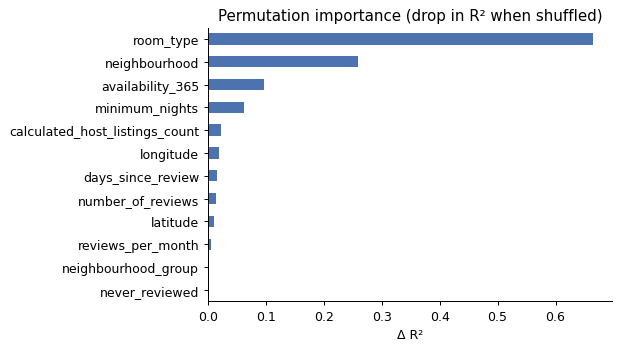

In [11]:
from sklearn.inspection import permutation_importance

sample = X_test_gb.sample(3000, random_state=RANDOM_STATE)
imp = permutation_importance(gbm, sample, y_test.loc[sample.index], n_repeats=5,
                             random_state=RANDOM_STATE, scoring="r2")
importance = pd.Series(imp.importances_mean, index=sample.columns).sort_values()
ax = importance.plot.barh(figsize=(7, 4), color="#4C72B0")
ax.set(title="Permutation importance (drop in R² when shuffled)", xlabel="Δ R²")
plt.tight_layout(); plt.show()

### Where is the model wrong?

In [12]:
pred_test = np.expm1(gbm.predict(X_test_gb))
err = pd.DataFrame({"actual": price_test, "pred": pred_test,
                    "room_type": X_test.room_type})
err["abs_pct_err"] = (err.pred - err.actual).abs() / err.actual
bands = pd.cut(err.actual, [0, 75, 150, 300, 1000], labels=["≤$75", "$75–150", "$150–300", "$300–1000"])
err.groupby(bands, observed=True).agg(listings=("actual", "size"),
                                     median_abs_pct_error=("abs_pct_err", "median"))

,listings,median_abs_pct_error
actual,,
≤$75,3102,0.23
$75–150,3704,0.23
$150–300,2275,0.20
$300–1000,648,0.49


## 4. Conclusions

**Findings from the data**
- **Room type is the single biggest price driver** — an entire home in Manhattan has a median of \$190/night vs \$90 for a private room. It alone accounts for most of the model's predictive power.
- **Neighbourhood matters more than borough.** Once the model knows the specific neighbourhood, the borough label adds nothing (its permutation importance is ~0) — the dashboard's borough-level view hides a lot of within-borough variation.
- **The market is partly professionalised:** 13.8% of hosts have more than one listing, and they own 33.9% of all listings; the top 1% of hosts own 10.1%.

**Model results (held-out test set, listings ≤ \$1,000/night)**

| Model | MAE | Median abs. error | R² (log price) |
|---|---|---|---|
| Baseline: borough × room-type median | \$54.10 | \$28.00 | 0.48 |
| Ridge regression | \$49.61 | \$25.17 | 0.58 |
| Gradient boosting | **\$45.50** | **\$22.87** | **0.65** |

Gradient boosting cuts the average error by about **16%** versus the baseline. That's a real but **modest** gain: for a typical listing it's off by roughly 20–25%, and for listings above \$300 the typical error doubles to ~49%.

**Why not better?** The dataset doesn't contain what most determines price — size, number of bedrooms, amenities, photos, and listing quality. Those are in the full Inside Airbnb scrape, and adding them is the obvious next step.

**Limitations**
- These are *listed* prices, not prices actually paid.
- A single 2019 snapshot — no seasonality.
- Listings above \$1,000/night (0.5%) are excluded, so the model shouldn't be used for luxury listings.

**Possible extensions:** add amenity/size features from the full Inside Airbnb data, use the listing title text (TF-IDF or embeddings), and validate on a newer snapshot to check the model still holds.